In [35]:

! pip install scikit-fuzzy
! pip install scipy
! pip install networkx
! pip install matplotlib



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [37]:
# Variáveis
temperatura = ctrl.Antecedent(np.arange(0, 46, 1), 'temperatura')
conforto = ctrl.Consequent(np.arange(0, 46, 1), 'conforto')

In [38]:
# Conjunto Fuzzy (temperatura)
temperatura['frio'] = fuzz.trimf(temperatura.universe, [0, 15, 25])
temperatura['agradavel'] = fuzz.trimf(temperatura.universe, [15, 25, 35])
temperatura['quente'] = fuzz.trimf(temperatura.universe, [25, 35, 45])

In [ ]:
# Conjunto Fuzzy (conforto)
conforto['baixo'] = fuzz.trimf(conforto.universe, [0, 15, 25])
conforto['medio'] = fuzz.trimf(conforto.universe, [25, 35, 45])
conforto['alto'] = fuzz.trimf(conforto.universe, [15, 25, 35])

In [40]:
# Regras Fuzzy
regra1 = ctrl.Rule(temperatura['frio'], conforto['baixo'])
regra2 = ctrl.Rule(temperatura['quente'], conforto['medio'])
regra3 = ctrl.Rule(temperatura['agradavel'], conforto['alto'])

In [41]:
# Sistema de controle
sistema = ctrl.ControlSystem([regra1, regra2, regra3])
simulador = ctrl.ControlSystemSimulation(sistema)

In [42]:
# Exemplo
x = simulador.input['temperatura'] = 28
simulador.compute()

# Resultado
print(f"Temperatura: {x}°C -> Conforto {simulador.output['conforto']:.2f}")

Temperatura: 28°C -> Conforto 28.35


In [ ]:
# Visualizar regras
def regras_ativas():
    try:
        
        t_input = float(input("Por favor, digite a temperatura em °C: "))
        
        if t_input < temperatura.universe[0] or t_input > temperatura.universe[-1]:
            print(f'Temperatura está fora do intervalo permitido ({temperatura.universe[0]}°C a {temperatura.universe[-1]}°C)')
            return

    except ValueError:
        print('Entrada inválida digite um número.')
        return
        
    print(f"Temperature: {t_input}°C")
    
    # Calcular o grau de pertinência
    grau_frio = fuzz.interp_membership(temperatura.universe, temperatura['frio'].mf, t_input)
    grau_agradavel = fuzz.interp_membership(temperatura.universe, temperatura['agradavel'].mf, t_input)
    grau_quente = fuzz.interp_membership(temperatura.universe, temperatura['quente'].mf, t_input)
    
    if grau_frio > 0:
        print(f"\t-> Regra 1: FRIO -> Conforto BAIXO (grau de ativação): {(grau_frio * 100):.2f}%")
    if grau_agradavel > 0:
        print(f"\t-> Regra 2: AGRADÁVEL -> Conforto ALTO (grau de ativação): {(grau_agradavel * 100):.2f}%")
    if grau_quente > 0:
        print(f"\t-> Regra 2: QUENTE -> Conforto BAIXO (grau de ativação): {(grau_quente * 100):.2f}%")

    try:
        simulador.input['temperatura'] = t_input
        simulador.compute()
        conforto_resultado = simulador.output['conforto']
        print(f'\n Resultado fuzzy: Conforto = {conforto_resultado:.2f}')
    except Exception as e:
        print('Simulador não está definido ou variável conforto não foi configurada.')
        print(e)
        
regras_ativas()

# Visualização
temperatura.view(sim=simulador)
conforto.view(sim=simulador)

In [55]:
nota = ctrl.Antecedent(np.arange(0, 11, 1), 'nota')
clareza = ctrl.Consequent(np.arange(0, 11, 1), 'clareza')

In [56]:
nota['ruim'] = fuzz.trapmf(nota.universe, [0, 0, 3, 5])
nota['boa'] = fuzz.trapmf(nota.universe, [3, 5, 7, 9])
nota['exelente'] = fuzz.trapmf(nota.universe, [7, 9, 10, 10])

clareza['ruim'] = fuzz.trapmf(clareza.universe, [0, 0, 3, 5])
clareza['boa'] = fuzz.trapmf(clareza.universe, [3, 5, 7, 9])
clareza['exelente'] = fuzz.trapmf(clareza.universe, [7, 9, 10, 10])

In [57]:
regra1 = ctrl.Rule(nota['ruim'], clareza['ruim'])
regra2 = ctrl.Rule(nota['boa'], clareza['boa'])
regra3 = ctrl.Rule(nota['exelente'], clareza['exelente'])

In [60]:
sistema = ctrl.ControlSystem([regra1, regra2, regra3])
simulador = ctrl.ControlSystemSimulation(sistema)

x = simulador.input['nota'] = 9
simulador.compute()

# Resultado
print(f"Nota: {x}°C -> Clareza do trabalho {simulador.output['clareza']:.2f}")

Nota: 9°C -> Clareza do trabalho 8.92


c:\Users\yastr\AppData\Local\Programs\Python\Python313\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


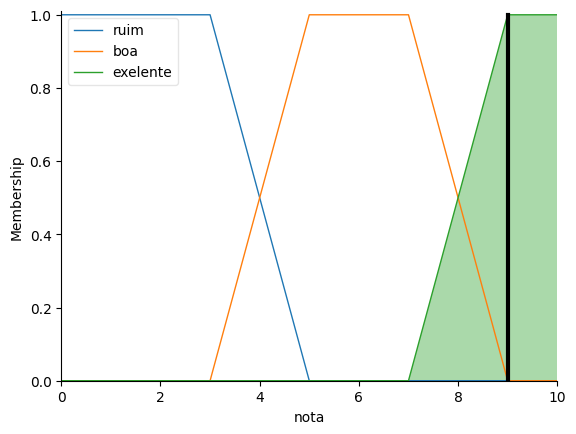

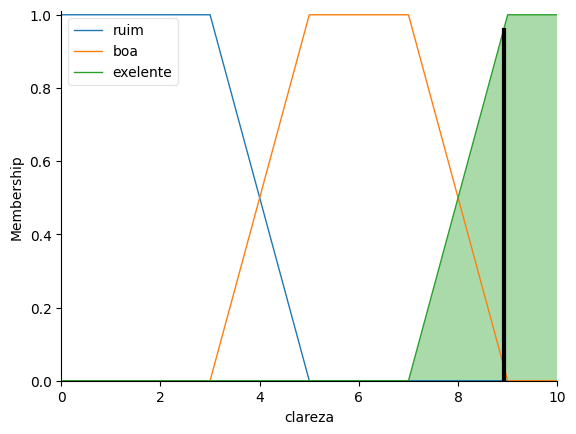

In [61]:
nota.view(sim=simulador)
clareza.view(sim=simulador)